# Повний аналіз даних — Wine Quality (UCI)
**Комплексна робота: від основ Python до кластеризації, на одному наборі даних**

## Про датасет

**Wine Quality** — класичний набір даних UCI Machine Learning Repository. Містить фізико-хімічні виміри (кислотність, цукор, сульфати, вміст спирту тощо) для зразків португальського вина "Vinho Verde" двох типів — червоного та білого, а також оцінку якості (0-10), виставлену дегустаторами.

- Джерело: Cortez et al., 2009, UCI ML Repository
- Червоне вино: 1599 зразків, Біле вино: 4898 зразків
- 11 числових фізико-хімічних ознак + цільова змінна `quality`
- Після об'єднання маємо ще й категоріальну ознаку `wine_type` (red/white)

## Чому цей датасет підходить для всієї роботи

| Розділ оригінальної практики | Що робимо тут |
|---|---|
| 1. Python, NumPy, Matplotlib | Розділ 1 — обробка сирих даних без Pandas |
| 2. Pandas, custom dataset | Розділ 2 — завантаження, об'єднання, очистка |
| 3. Візуалізація | Розділ 3 — гістограми, boxplot, scatter, heatmap |
| 4. Регресія | Розділ 4 — Linear Regression + Polyfit |
| 5. Класифікація | Розділ 5 — Scaler, Encoder, Decision Tree, KNN, SVM |
| 6. Кластеризація + зниження розмірності | Розділ 6 — K-means, EM, PCA |
| 7. NLP (NLTK) | **Не застосовується** — див. примітку в кінці |

> **Примітка щодо розділу 7 (NLP).** Обробка природної мови працює з текстовими даними (речення, документи), а Wine Quality — суто табличний датасет із числовими вимірами. Жоден зі стовпців не є текстом, тому методи NLTK (токенізація, очистка регулярними виразами, класифікація тексту) тут технічно незастосовні. Це природне обмеження модальності даних, а не недолік плану: жоден єдиний "звичайний" датасет не покриє одразу і табличний ML, і NLP. Якщо розділ 7 обов'язковий до здачі — знадобиться окремий текстовий корпус.

## Розділ 0. Імпорти та налаштування

Всі бібліотеки, які знадобляться протягом ноутбука, імпортуємо одразу на початку — це стандартна практика, яка робить залежності коду видимими з першого погляду.

In [1]:
# --- Робота з даними ---
import numpy as np              # операції з масивами, лінійна алгебра, статистика
import pandas as pd             # табличні дані (DataFrame), читання CSV, групування

# --- Візуалізація ---
import matplotlib.pyplot as plt # базові графіки (лінії, scatter, гістограми)
import seaborn as sns           # надбудова над matplotlib: красивіші графіки "з коробки"

# --- Машинне навчання: підготовка даних ---
from sklearn.model_selection import train_test_split   # розбиття на train/test
from sklearn.preprocessing import StandardScaler        # масштабування ознак
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  # кодування категорій

# --- Машинне навчання: регресія ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Машинне навчання: класифікація ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Машинне навчання: кластеризація та зниження розмірності ---
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture   # EM-кластеризація
from sklearn.decomposition import PCA

# --- Налаштування зовнішнього вигляду графіків ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# --- Фіксуємо random_state для відтворюваності результатів ---
# Без цього кожен запуск train_test_split чи KMeans давав би трохи інші числа.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Бібліотеки імпортовано, середовище готове.')

Бібліотеки імпортовано, середовище готове.


## Розділ 1. Основи Python, NumPy, Matplotlib

Перш ніж підключати Pandas, попрацюємо з даними "сирими" засобами — чистим Python та NumPy. Це відповідає першій практичній: розуміння того, що Pandas робить "під капотом", починається з розуміння списків і масивів.

### 1.1 Python: читання CSV без Pandas і робота зі списками

In [2]:
import csv
import urllib.request

# URL офіційного дзеркала датасету на GitHub (сирий CSV, роздільник ';')
URL_RED = 'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-red.csv'

# Завантажуємо файл у пам'ять і читаємо його рядок за рядком через csv.reader.
# Це навмисно "ручний" спосіб — без pandas.read_csv — щоб побачити, з чим
# насправді працює Pandas всередині.
with urllib.request.urlopen(URL_RED) as response:
    text = response.read().decode('utf-8')

rows = list(csv.reader(text.splitlines(), delimiter=';'))
header = rows[0]                 # перший рядок — назви колонок
data_rows = rows[1:]             # решта — самі дані (рядки-списки рядків-текстів)

print('Заголовок:', header)
print('Кількість рядків даних:', len(data_rows))
print('Перший рядок (як список текстів):', data_rows[0])

Заголовок: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Кількість рядків даних: 1599
Перший рядок (як список текстів): ['7.4', '0.7', '0', '1.9', '0.076', '11', '34', '0.9978', '3.51', '0.56', '9.4', '5']


In [3]:
# Значення прочитались як текст (str), а не числа. Дістанемо стовпець
# "alcohol" (вміст спирту) і "quality" (оцінка) вручну через list comprehension —
# класична вправа зі списками з першої практичної.

idx_alcohol = header.index('alcohol')
idx_quality = header.index('quality')

# List comprehension: перетворюємо текст на float/int для кожного рядка
alcohol_list = [float(row[idx_alcohol]) for row in data_rows]
quality_list = [int(row[idx_quality]) for row in data_rows]

print('Перші 5 значень alcohol:', alcohol_list[:5])
print('Перші 5 значень quality:', quality_list[:5])

# Зріз (slice): останні 5 значень
print('Останні 5 значень alcohol:', alcohol_list[-5:])

# Пошук максимуму й мінімуму "вручну", без вбудованих max()/min(),
# щоб побачити, що ці функції роблять під капотом
max_alcohol = alcohol_list[0]
for value in alcohol_list:
    if value > max_alcohol:
        max_alcohol = value
print('Максимальний вміст спирту (знайдено циклом):', max_alcohol)
print('Максимальний вміст спирту (вбудований max()):', max(alcohol_list))  # для перевірки — числа мають збігтись

Перші 5 значень alcohol: [9.4, 9.8, 9.8, 9.8, 9.4]
Перші 5 значень quality: [5, 5, 5, 6, 5]
Останні 5 значень alcohol: [10.5, 11.2, 11.0, 10.2, 11.0]
Максимальний вміст спирту (знайдено циклом): 14.9
Максимальний вміст спирту (вбудований max()): 14.9


### 1.2 NumPy: перехід від списків до масивів

In [4]:
# Перетворюємо звичайні Python-списки на numpy-масиви.
# Різниця стає видною одразу: операції з масивами — поелементні (векторизовані),
# на відміну від списків, де "+" означає конкатенацію, а не додавання чисел.
alcohol_arr = np.array(alcohol_list)
quality_arr = np.array(quality_list)

print('Тип об'"'"'єкта:', type(alcohol_arr))
print('Форма масиву (shape):', alcohol_arr.shape)
print('Середнє значення (mean):', round(alcohol_arr.mean(), 3))
print('Стандартне відхилення (std):', round(alcohol_arr.std(), 3))
print('Медіана:', round(np.median(alcohol_arr), 3))

# Булева індексація (boolean mask) — потужний прийом NumPy:
# вибираємо лише ті вина, де quality >= 7 ("добрі" вина)
good_mask = quality_arr >= 7
print()
print('Кількість "добрих" вин (quality >= 7):', good_mask.sum())
print('Середній вміст спирту серед добрих вин:', round(alcohol_arr[good_mask].mean(), 3))
print('Середній вміст спирту серед решти вин:', round(alcohol_arr[~good_mask].mean(), 3))
# ~good_mask — інверсія маски (побітове "НЕ"): усе, що НЕ добре

Тип об'єкта: <class 'numpy.ndarray'>
Форма масиву (shape): (1599,)
Середнє значення (mean): 10.423
Стандартне відхилення (std): 1.065
Медіана: 10.2

Кількість "добрих" вин (quality >= 7): 217
Середній вміст спирту серед добрих вин: 11.518
Середній вміст спирту серед решти вин: 10.251


In [5]:
# np.random.seed фіксує генератор випадкових чисел — це основа відтворюваності
# експериментів у машинному навчанні (той самий seed -> той самий результат).
np.random.seed(RANDOM_STATE)

# Візьмемо випадкову підвибірку індексів без повторень (без replacement)
sample_idx = np.random.choice(len(alcohol_arr), size=5, replace=False)
print('Випадкові індекси:', sample_idx)
print('Відповідні значення alcohol:', alcohol_arr[sample_idx])

# argmax повертає ІНДЕКС максимуму, а не саме значення — важлива відмінність від max()
idx_of_max = alcohol_arr.argmax()
print()
print(f'Індекс вина з найвищим вмістом спирту: {idx_of_max}')
print(f'Його вміст спирту: {alcohol_arr[idx_of_max]}, оцінка якості: {quality_arr[idx_of_max]}')

Випадкові індекси: [ 803  124  350  682 1326]
Відповідні значення alcohol: [ 9.6  9.5  9.9  9.8 10.6]

Індекс вина з найвищим вмістом спирту: 652
Його вміст спирту: 14.9, оцінка якості: 5


### 1.3 Matplotlib: перший погляд на дані через графік

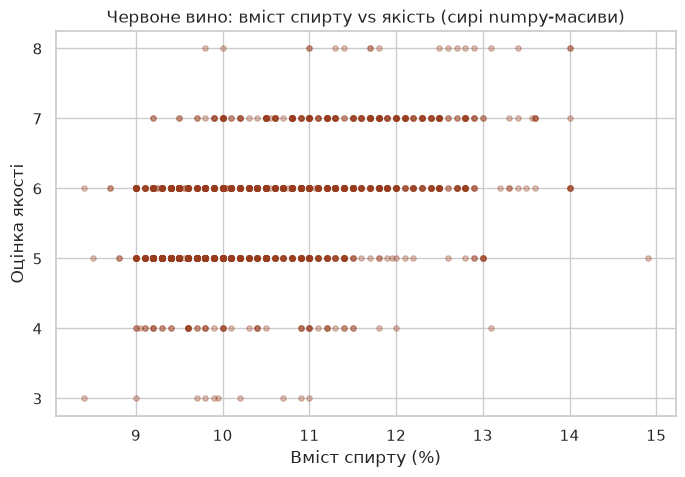

In [6]:
# Найпростіший графік — scatter (розсіювання) alcohol проти quality,
# побудований прямо з numpy-масивів, ще до знайомства з Pandas.
plt.figure(figsize=(8, 5))
plt.scatter(alcohol_arr, quality_arr, alpha=0.3, s=15, color='#993C1D')
plt.xlabel('Вміст спирту (%)')
plt.ylabel('Оцінка якості')
plt.title('Червоне вино: вміст спирту vs якість (сирі numpy-масиви)')
plt.show()
# Навіть на цьому базовому графіку помітна слабка висхідна тенденція:
# вина з вищим вмістом спирту частіше отримують вищу оцінку.

## Розділ 2. Pandas: завантаження, об'єднання, очистка

Тепер переходимо на Pandas — саме тут почнеться "справжня" робота з даними. Завантажимо обидва файли (червоне і біле вино), об'єднаємо їх в один DataFrame і підготуємо до аналізу.

In [7]:
URL_WHITE = 'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-white.csv'

# pd.read_csv одразу перетворює текстовий CSV на структурований DataFrame
# з правильними типами колонок (float64, int64) — те, що ми щойно робили вручну.
df_red = pd.read_csv(URL_RED, sep=';')
df_white = pd.read_csv(URL_WHITE, sep=';')

# Додаємо категоріальну ознаку "тип вина" -- її не було в жодному з файлів окремо,
# вона з'являється лише в момент об'єднання. Це знадобиться пізніше для Encoder.
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# concat склеює два DataFrame по рядках (як vstack для таблиць).
# ignore_index=True перенумеровує рядки 0..N, а не залишає дублікати індексів.
df = pd.concat([df_red, df_white], ignore_index=True)

print('Розмір після об\'єднання:', df.shape)
df.head()

Розмір після об'єднання: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [8]:
# info() показує типи колонок і кількість непорожніх значень в одному звіті —
# перше, що варто перевірити для будь-якого нового датасету.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [9]:
# describe() дає описову статистику (мін/макс/квартилі/середнє) по всіх
# числових колонках одразу -- швидкий спосіб "відчути" масштаби ознак.
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.06,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


### Перевірка якості даних
Обов'язковий крок перед будь-яким аналізом: пропуски та дублікати спотворюють статистику й моделі, якщо їх не обробити.

In [10]:
# Пропущені значення по кожній колонці
print('Пропуски по колонках:')
print(df.isnull().sum())
print()
print('Загальна кількість пропусків:', df.isnull().sum().sum())
# У цьому датасеті пропусків немає -- UCI Wine Quality вже "чистий" за замовчуванням.

Пропуски по колонках:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Загальна кількість пропусків: 0


In [11]:
# А ось дублікати є -- і це реалістична ситуація (кілька дегустацій дали
# однакові виміри й однакову оцінку для різних фізичних зразків).
n_duplicates = df.duplicated().sum()
print('Кількість повних дублікатів рядків:', n_duplicates)

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Було {df.shape[0]} рядків -> залишилось {df_clean.shape[0]} рядків після видалення дублікатів')

# Далі працюємо виключно з очищеною версією df_clean
df = df_clean

Кількість повних дублікатів рядків: 1177
Було 6497 рядків -> залишилось 5320 рядків після видалення дублікатів


In [12]:
# Список числових ознак -- знадобиться в усіх наступних розділах,
# тому виносимо його в окрему змінну один раз.
num_cols = [c for c in df.columns if c not in ('wine_type', 'quality')]
print('Числові ознаки (11 шт.):')
print(num_cols)

Числові ознаки (11 шт.):
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [13]:
# groupby -- одна з найкорисніших функцій Pandas: рахує статистику
# окремо для кожної групи (тут -- окремо для червоного і білого вина).
df.groupby('wine_type')[num_cols].mean().round(2)
# Помітно: біле вино в середньому солодше (residual sugar) і має менше
# летючої кислотності (volatile acidity), ніж червоне.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
wine_type,,,,,,,,,,,
red,8.31,0.53,0.27,2.52,0.09,15.89,46.83,1.00,3.31,0.66,10.43
white,6.84,0.28,0.33,5.91,0.05,34.89,137.19,0.99,3.20,0.49,10.59


In [14]:
# value_counts -- розподіл значень категоріальної/дискретної колонки
print('Розподіл типів вина:')
print(df['wine_type'].value_counts())
print()
print('Розподіл оцінок якості:')
print(df['quality'].value_counts().sort_index())
# Видно, що оцінки 5 і 6 -- найпоширеніші (типовий "середній" смак),
# а екстремальні оцінки (3 і 9) -- рідкісні. Це називається дисбаланс класів
# і матиме значення в розділі 5 (класифікація).

Розподіл типів вина:
wine_type
white    3961
red      1359
Name: count, dtype: int64

Розподіл оцінок якості:
quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64


## Розділ 3. Візуалізація

Переходимо від таблиць чисел до графіків — саме тут стає видно закономірності, які важко помітити в `describe()`.

### 3.1 Одновимірний аналіз: розподіли числових ознак

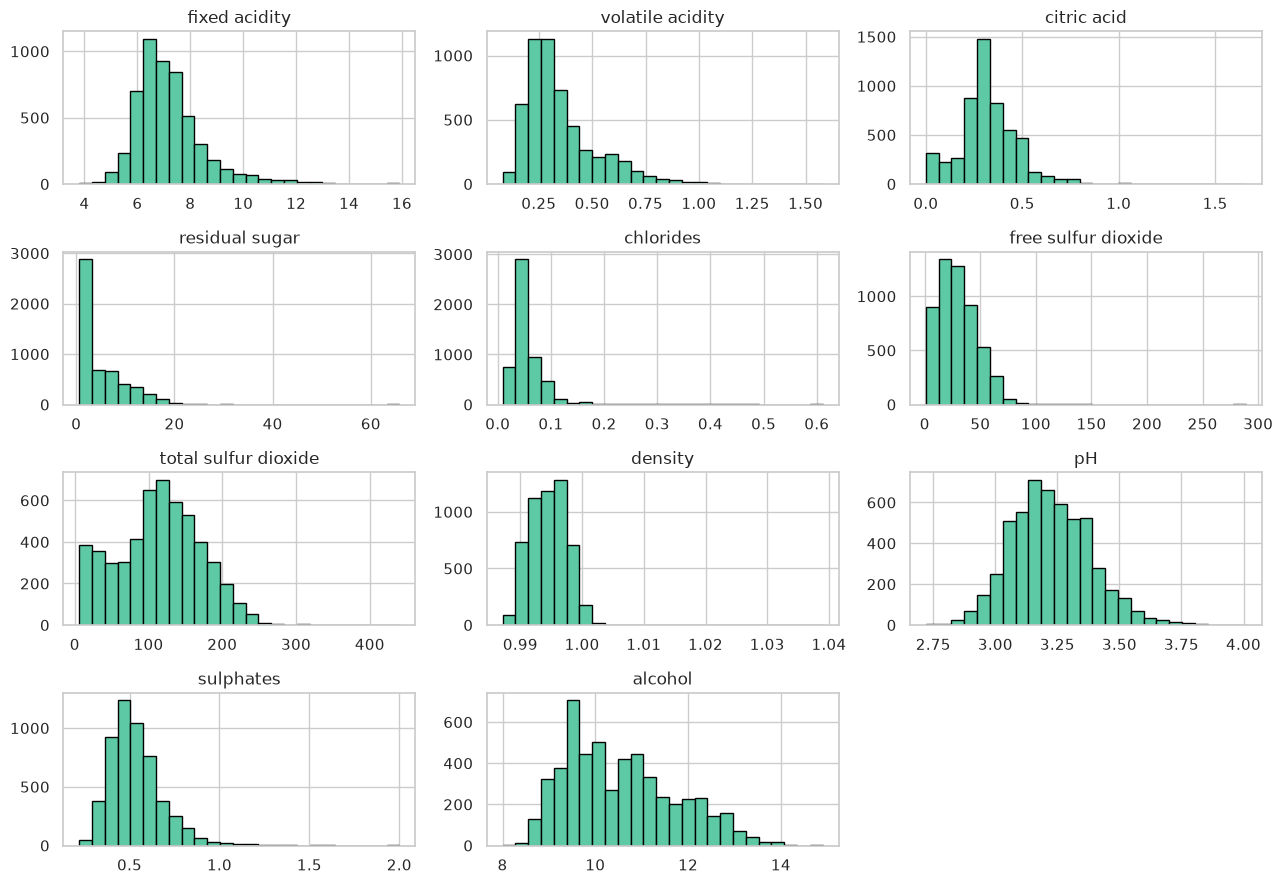

In [15]:
# hist() для DataFrame будує гістограму одразу для всіх числових колонок --
# зручно для швидкого огляду форми розподілу кожної ознаки.
df[num_cols].hist(bins=25, figsize=(13, 9), edgecolor='black', color='#5DCAA5')
plt.tight_layout()
plt.show()
# Зверни увагу на форму розподілів: більшість ознак скошені праворуч
# (є "хвіст" з рідкісних високих значень) -- типово для хімічних вимірів.

### 3.2 Якість вина за типом — boxplot

/tmp/ipykernel_137/3614436464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='wine_type', y='quality', palette=['#D85A30', '#F0997B'])


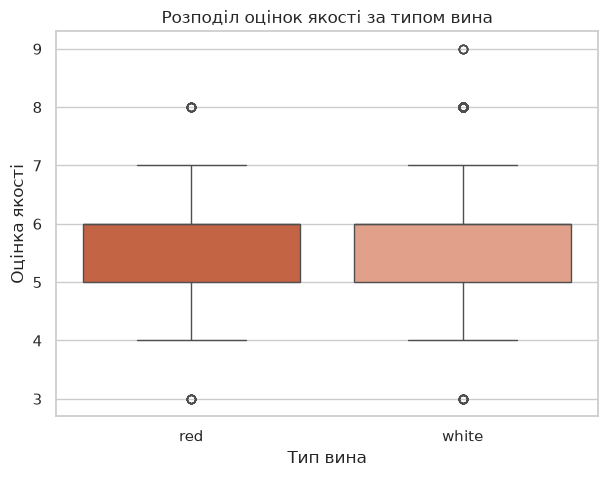

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='wine_type', y='quality', palette=['#D85A30', '#F0997B'])
plt.title('Розподіл оцінок якості за типом вина')
plt.xlabel('Тип вина')
plt.ylabel('Оцінка якості')
plt.show()
# boxplot показує медіану (лінія всередині "ящика"), міжквартильний розмах
# (сам "ящик") і викиди (окремі точки за "вусами").

### 3.3 Вміст спирту проти якості — scatter із розбивкою за типом

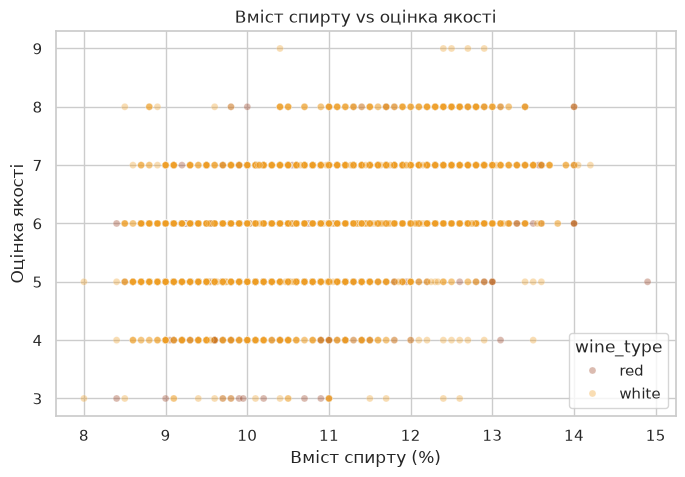

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='wine_type',
                 alpha=0.35, s=25, palette={'red': '#993C1D', 'white': '#EF9F27'})
plt.title('Вміст спирту vs оцінка якості')
plt.xlabel('Вміст спирту (%)')
plt.ylabel('Оцінка якості')
plt.show()

### 3.4 Кореляційна матриця числових ознак

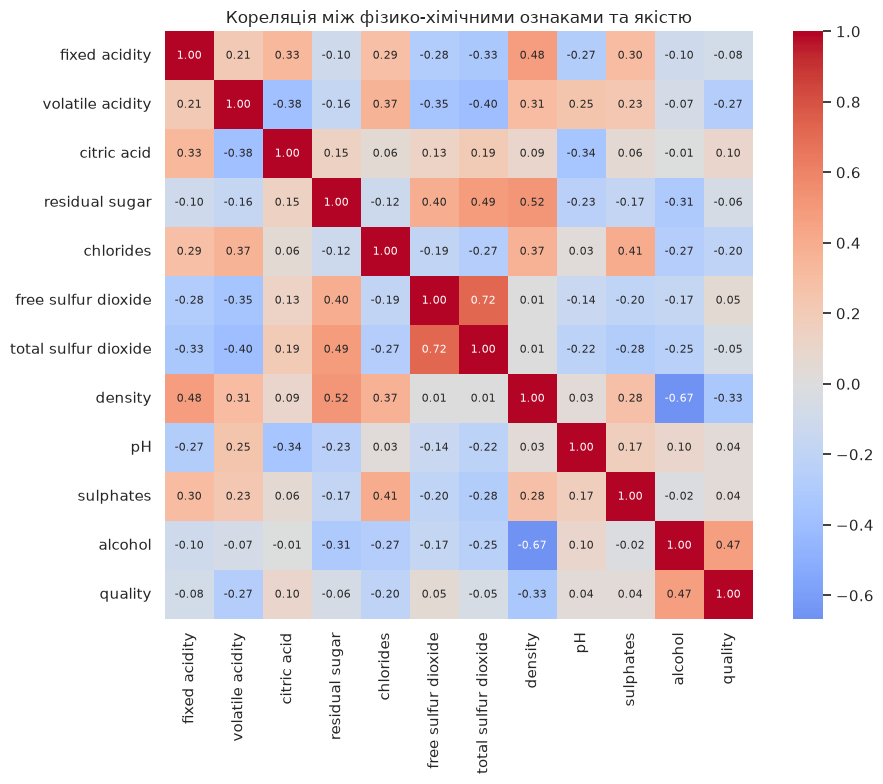

Кореляція кожної ознаки з quality, відсортована за модулем:
alcohol                 0.469
density                -0.326
volatile acidity       -0.265
chlorides              -0.202
citric acid             0.098
fixed acidity          -0.080
residual sugar         -0.057
free sulfur dioxide     0.054
total sulfur dioxide   -0.050
sulphates               0.042
pH                      0.040
Name: quality, dtype: float64


In [18]:
# corr() рахує коефіцієнт кореляції Пірсона між кожною парою колонок:
# значення від -1 (обернений зв'язок) до +1 (прямий зв'язок), 0 -- зв'язку немає.
corr = df[num_cols + ['quality']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            annot_kws={'size': 8})
plt.title('Кореляція між фізико-хімічними ознаками та якістю')
plt.tight_layout()
plt.show()

print('Кореляція кожної ознаки з quality, відсортована за модулем:')
print(corr['quality'].drop('quality').sort_values(key=abs, ascending=False).round(3))

### 3.5 Парні залежності (pairplot) — вибрані ознаки

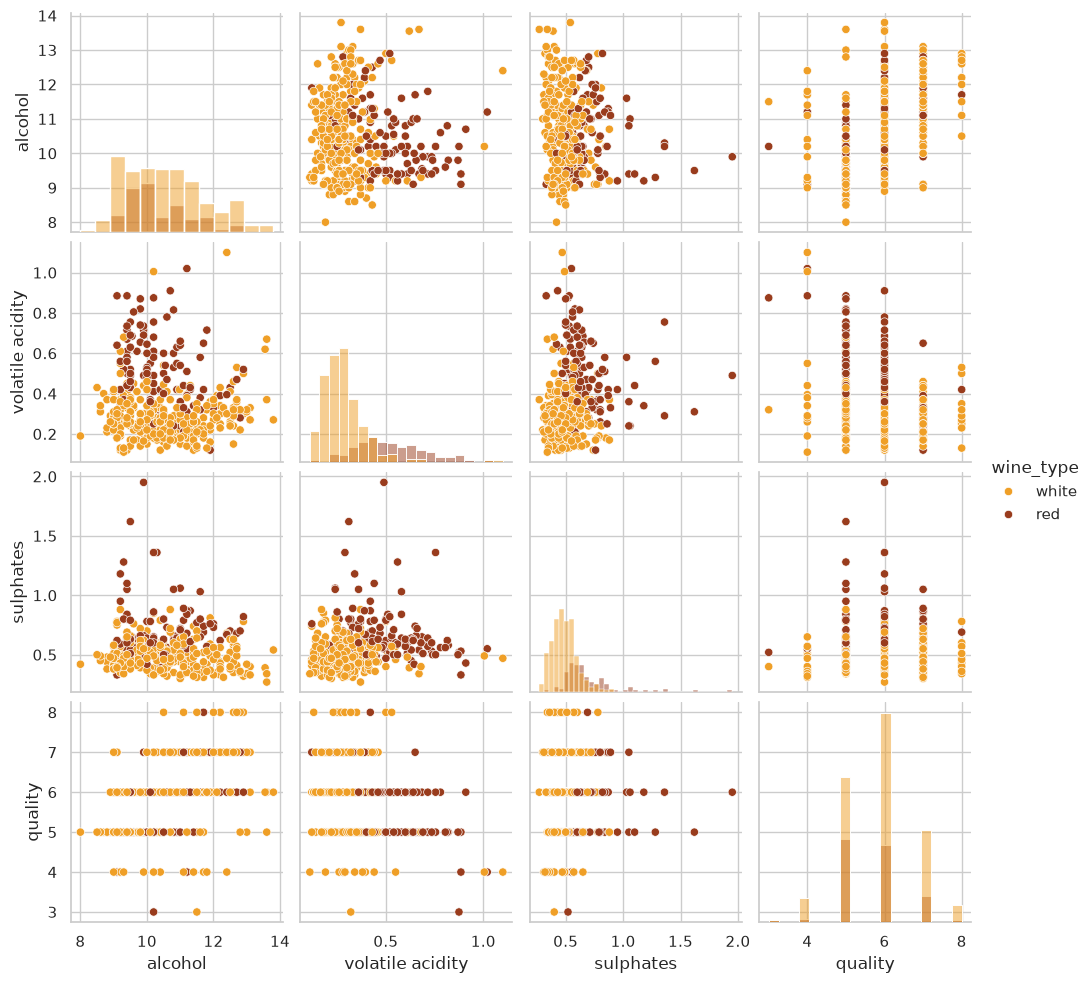

In [19]:
# pairplot на всіх 11 ознаках і 5000+ рядках був би дуже повільним і нечитабельним,
# тому будуємо його на: (1) невеликій випадковій вибірці рядків,
# (2) обмеженому наборі найбільш інформативних ознак (за кореляцією вище).
sample = df.sample(400, random_state=RANDOM_STATE)
subset_cols = ['alcohol', 'volatile acidity', 'sulphates', 'quality', 'wine_type']

sns.pairplot(sample[subset_cols], hue='wine_type',
             palette={'red': '#993C1D', 'white': '#EF9F27'}, diag_kind='hist')
plt.show()

## Розділ 4. Регресія

Мета: передбачити `quality` (число 3-9) на основі фізико-хімічних вимірів. Спочатку багатовимірна лінійна регресія на всіх ознаках, потім -- одновимірна поліноміальна (Polyfit) для наочної візуалізації нелінійного зв'язку.

### 4.1 Лінійна регресія (усі ознаки)

In [20]:
# Ознака wine_type -- текстова ('red'/'white'), а моделі регресії приймають
# лише числа. Тимчасово кодуємо її 0/1 через LabelEncoder (детальніше -- у розділі 5).
le_temp = LabelEncoder()
wine_type_encoded = le_temp.fit_transform(df['wine_type'])

X = df[num_cols].copy()
X['wine_type_encoded'] = wine_type_encoded
y = df['quality']

# Розбиваємо на навчальну (80%) і тестову (20%) вибірки.
# Модель НІКОЛИ не має бачити тестові дані під час навчання -- інакше
# оцінка якості буде оманливо оптимістичною.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Масштабування: ознаки мають дуже різні діапазони (density ~0.99, total sulfur ~150).
# StandardScaler приводить кожну ознаку до середнього 0 і стандартного відхилення 1,
# інакше ознаки з великими числами домінуватимуть у моделі штучно.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform -- навчаємось І трансформуємо
X_test_scaled = scaler.transform(X_test)         # transform -- лише трансформуємо (тими ж параметрами!)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5   # корінь із середньоквадратичної помилки

print(f'R² (частка поясненої дисперсії): {r2:.3f}')
print(f'RMSE (середня помилка в балах якості): {rmse:.3f}')
# R² ≈ 0.3 означає, що хімічні виміри пояснюють лише близько третини варіації
# оцінки якості -- решта залежить від суб'єктивного смаку дегустатора,
# який просто не закодований у цих ознаках. Це нормальний і очікуваний результат.

R² (частка поясненої дисперсії): 0.309
RMSE (середня помилка в балах якості): 0.721


In [21]:
# Коефіцієнти регресії показують, наскільки і в який бік кожна ознака
# впливає на прогноз (за умови, що решта ознак не змінюється).
coef_df = pd.DataFrame({
    'ознака': list(X.columns),
    'коефіцієнт': model.coef_
}).sort_values('коефіцієнт', key=abs, ascending=False)

print(coef_df.round(3).to_string(index=False))
# Додатний коефіцієнт -- ознака підвищує прогнозовану якість,
# від'ємний -- знижує. Через масштабування коефіцієнти порівнювані між собою.

              ознака  коефіцієнт
             alcohol       0.292
             density      -0.253
    volatile acidity      -0.225
      residual sugar       0.219
   wine_type_encoded      -0.120
           sulphates       0.120
 free sulfur dioxide       0.106
total sulfur dioxide      -0.100
                  pH       0.081
       fixed acidity       0.079
           chlorides      -0.036
         citric acid       0.022


### 4.2 Поліноміальна регресія (Polyfit) на одній ознаці

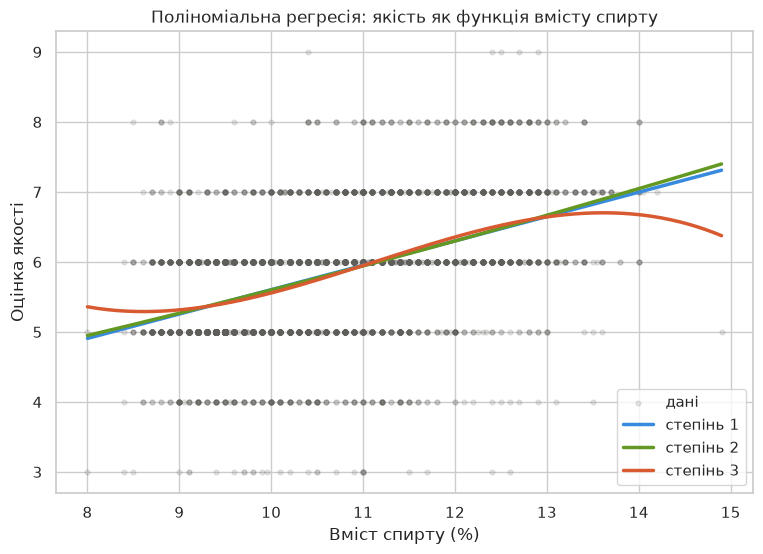

In [22]:
# np.polyfit підбирає коефіцієнти поліному заданого степеня методом найменших
# квадратів для ОДНІЄЇ пари (x, y) -- зручно для наочної візуалізації нелінійності.
x_data = df['alcohol'].values
y_data = df['quality'].values

# Пробуємо три степені полінома: 1 (пряма лінія), 2 (парабола), 3 (кубічна крива)
degrees = [1, 2, 3]
x_line = np.linspace(x_data.min(), x_data.max(), 200)  # 200 точок для гладкої лінії

plt.figure(figsize=(9, 6))
plt.scatter(x_data, y_data, alpha=0.15, s=12, color='#5F5E5A', label='дані')

colors = ['#378ADD', '#639922', '#D85A30']
for degree, color in zip(degrees, colors):
    coefs = np.polyfit(x_data, y_data, deg=degree)
    poly_func = np.poly1d(coefs)          # перетворює коефіцієнти на функцію, яку можна викликати
    y_line = poly_func(x_line)
    plt.plot(x_line, y_line, color=color, linewidth=2.5, label=f'степінь {degree}')

plt.xlabel('Вміст спирту (%)')
plt.ylabel('Оцінка якості')
plt.title('Поліноміальна регресія: якість як функція вмісту спирту')
plt.legend()
plt.show()
# Криві різних степенів майже збігаються -- ознака цей зв'язок майже лінійний,
# ускладнення моделі (вищий степінь) тут не дає суттєвої переваги.

## Розділ 5. Класифікація

Замість передбачення точного балу (0-10) спростимо задачу до бінарної: чи є вино "добрим" (`quality >= 7`) чи ні. Це типовий підхід, коли неперервну оцінку зручніше аналізувати як категорію.

In [23]:
# Створюємо бінарну цільову змінну
df['quality_label'] = (df['quality'] >= 7).astype(int)   # 1 = добре вино, 0 = звичайне

print(df['quality_label'].value_counts())
print(f"""
Частка "добрих" вин: {df['quality_label'].mean():.1%}
""")
# Класи незбалансовані (добрих вин суттєво менше) -- тому дивитись лише
# на accuracy буде недостатньо, знадобиться classification_report.

quality_label
0    4311
1    1009
Name: count, dtype: int64

Частка "добрих" вин: 19.0%



### 5.1 Encoder — кодування категоріальної ознаки

In [24]:
# LabelEncoder перетворює текстові категорії на цілі числа: 'red' -> 0, 'white' -> 1.
# Підходить, коли категорій дві (або є природний порядок).
label_encoder = LabelEncoder()
df['wine_type_le'] = label_encoder.fit_transform(df['wine_type'])
print('LabelEncoder:', dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

# OneHotEncoder -- альтернатива, яка створює окрему бінарну колонку на кожну
# категорію. Для двох категорій це надлишково, але демонструємо для повноти,
# оскільки саме so зазвичай кодують ознаки з 3+ категоріями (де LabelEncoder
# помилково нав'язав би категоріям штучний порядок 0 < 1 < 2).
onehot = OneHotEncoder(sparse_output=False)
onehot_result = onehot.fit_transform(df[['wine_type']])
onehot_df = pd.DataFrame(onehot_result, columns=onehot.get_feature_names_out(['wine_type']))
print()
print('OneHotEncoder (перші 5 рядків):')
print(onehot_df.head())

LabelEncoder: {'red': 0, 'white': 1}

OneHotEncoder (перші 5 рядків):
   wine_type_red  wine_type_white
0            1.0              0.0
1            1.0              0.0
2            1.0              0.0
3            1.0              0.0
4            1.0              0.0


### 5.2 Scaler — навіщо масштабувати ознаки

In [25]:
# Порівняємо діапазони ознак ДО масштабування
print('До масштабування (описова статистика вибраних ознак):')
print(df[['density', 'total sulfur dioxide', 'chlorides']].describe().round(3))

X_for_scaling = df[num_cols]
scaler_demo = StandardScaler()
X_scaled_demo = scaler_demo.fit_transform(X_for_scaling)

print()
print('Після масштабування (середнє ≈ 0, std ≈ 1 для ВСІХ ознак):')
print(pd.DataFrame(X_scaled_demo, columns=num_cols).describe().round(3).loc[['mean', 'std']])
# KNN і SVM рахують відстані між точками -- без масштабування ознака
# total_sulfur_dioxide (значення ~150) домінувала б над chlorides (значення ~0.05)
# лише через різницю в одиницях виміру, а не через реальну важливість.

До масштабування (описова статистика вибраних ознак):
        density  total sulfur dioxide  chlorides
count  5320.000              5320.000   5320.000
mean      0.995               114.109      0.057
std       0.003                56.774      0.037
min       0.987                 6.000      0.009
25%       0.992                74.000      0.038
50%       0.995               116.000      0.047
75%       0.997               153.250      0.066
max       1.039               440.000      0.611

Після масштабування (середнє ≈ 0, std ≈ 1 для ВСІХ ознак):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean            0.0              -0.0          0.0             0.0        0.0   
std             1.0               1.0          1.0             1.0        1.0   

      free sulfur dioxide  total sulfur dioxide  density   pH  sulphates  \
mean                  0.0                  -0.0      0.0  0.0       -0.0   
std                   1.0                   1.0  

### 5.3 Підготовка вибірок для класифікації

In [26]:
X = df[num_cols + ['wine_type_le']]
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y   # stratify зберігає те саме співвідношення класів у train і test,
                 # що критично важливо при дисбалансі класів
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} рядків, Test: {X_test.shape[0]} рядків')
print(f'Частка добрих вин у train: {y_train.mean():.1%}, у test: {y_test.mean():.1%}')
# Завдяки stratify частки майже однакові -- порівняння моделей буде чесним.

Train: 4256 рядків, Test: 1064 рядків
Частка добрих вин у train: 19.0%, у test: 19.0%


### 5.4 Decision Tree (дерево рішень)

In [27]:
# max_depth обмежує глибину дерева -- без обмеження дерево "заучує" тренувальні
# дані напам'ять (overfitting) і погано узагальнює на нових даних.
tree_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)   # дерева не потребують масштабування ознак
y_pred_tree = tree_model.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
print(f'Decision Tree accuracy: {acc_tree:.3f}')
print()
print(classification_report(y_test, y_pred_tree, target_names=['звичайне', 'добре']))

Decision Tree accuracy: 0.816

              precision    recall  f1-score   support

    звичайне       0.85      0.93      0.89       862
       добре       0.52      0.32      0.40       202

    accuracy                           0.82      1064
   macro avg       0.69      0.63      0.65      1064
weighted avg       0.79      0.82      0.80      1064



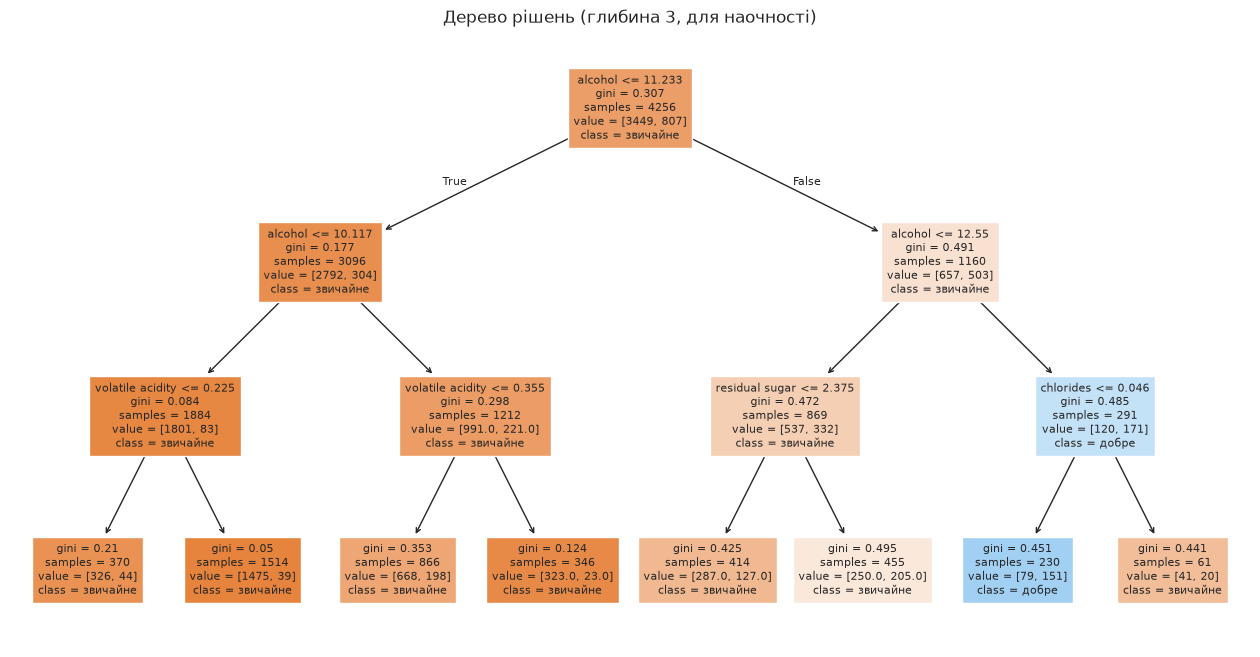

In [28]:
# Візуалізація самого дерева -- унікальна перевага цього алгоритму:
# на відміну від KNN чи SVM, рішення дерева можна прочитати "по кроках".
# Обмежуємо глибину до 3 лише для картинки (щоб влізла на екран) --
# сама модель вище навчена з глибиною 5.
tree_for_plot = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_for_plot.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(tree_for_plot, feature_names=list(X.columns),
          class_names=['звичайне', 'добре'], filled=True, fontsize=8)
plt.title('Дерево рішень (глибина 3, для наочності)')
plt.show()

### 5.5 K Nearest Neighbors (KNN)

In [29]:
# KNN класифікує точку "голосуванням" k найближчих сусідів у просторі ознак.
# Потребує масштабованих даних (X_train_scaled), бо базується на відстанях.
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN (k=7) accuracy: {acc_knn:.3f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['звичайне', 'добре']))

KNN (k=7) accuracy: 0.839

              precision    recall  f1-score   support

    звичайне       0.87      0.94      0.90       862
       добре       0.61      0.42      0.50       202

    accuracy                           0.84      1064
   macro avg       0.74      0.68      0.70      1064
weighted avg       0.82      0.84      0.83      1064



### 5.6 SVM — лінійне ядро

In [30]:
# SVM з лінійним ядром шукає пряму (гіперплощину), яка найкраще розділяє класи.
svm_linear = SVC(kernel='linear', random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_lin = svm_linear.predict(X_test_scaled)

acc_svm_lin = accuracy_score(y_test, y_pred_svm_lin)
print(f'SVM (linear kernel) accuracy: {acc_svm_lin:.3f}')

SVM (linear kernel) accuracy: 0.810


### 5.7 SVM — ядро RBF (нелінійне)

SVM (RBF kernel) accuracy: 0.833


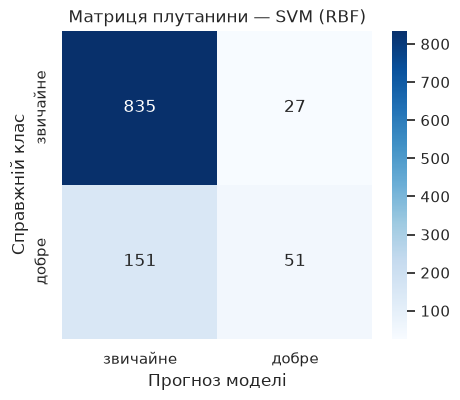

In [31]:
# RBF (Radial Basis Function) ядро дозволяє SVM будувати НЕлінійні межі
# розділення класів -- корисно, коли класи не розділяються прямою лінією.
svm_rbf = SVC(kernel='rbf', random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

acc_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
print(f'SVM (RBF kernel) accuracy: {acc_svm_rbf:.3f}')

# Матриця плутанини (confusion matrix) для найкращої з моделей поки що --
# показує не лише загальну точність, а ЯКІ саме помилки модель робить:
# плутає "добре" зі "звичайним" чи навпаки.
cm = confusion_matrix(y_test, y_pred_svm_rbf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['звичайне', 'добре'], yticklabels=['звичайне', 'добре'])
plt.xlabel('Прогноз моделі')
plt.ylabel('Справжній клас')
plt.title('Матриця плутанини — SVM (RBF)')
plt.show()

### 5.8 Порівняння всіх моделей класифікації

       Модель  Accuracy
    KNN (k=7)  0.839286
    SVM (RBF)  0.832707
Decision Tree  0.815789
 SVM (linear)  0.810150


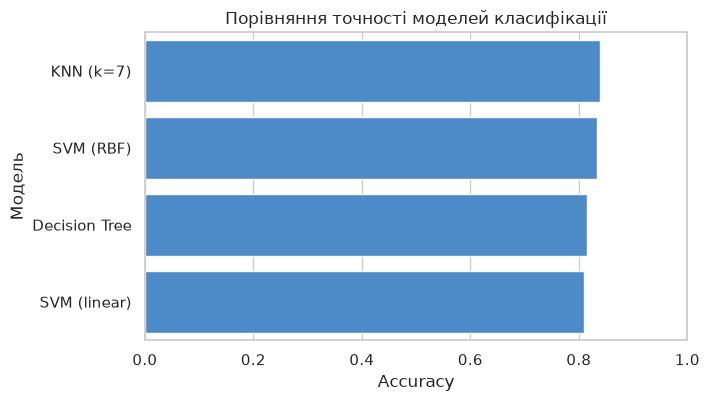

In [32]:
results = pd.DataFrame({
    'Модель': ['Decision Tree', 'KNN (k=7)', 'SVM (linear)', 'SVM (RBF)'],
    'Accuracy': [acc_tree, acc_knn, acc_svm_lin, acc_svm_rbf]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=results, x='Accuracy', y='Модель', color='#378ADD')
plt.xlim(0, 1)
plt.title('Порівняння точності моделей класифікації')
plt.show()

## Розділ 6. Кластеризація та зниження розмірності

Тут ми "забуваємо" про мітки (`wine_type`, `quality`) і просимо алгоритм самостійно знайти структуру в даних лише за фізико-хімічними ознаками -- це і є суть навчання без учителя (unsupervised learning).

### 6.1 K-means: пошук оптимальної кількості кластерів (метод ліктя)

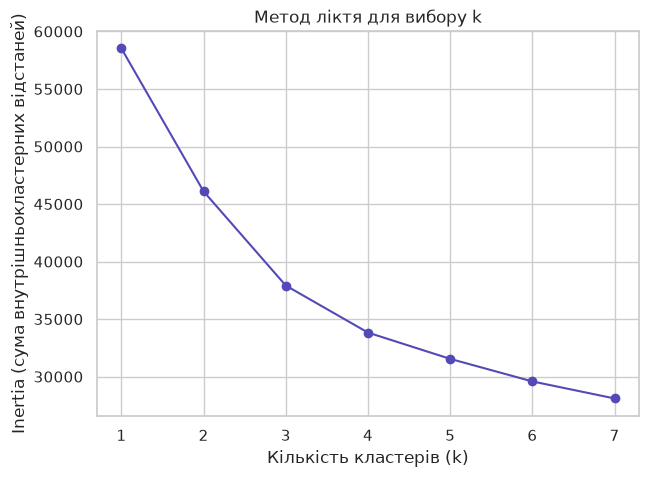

In [33]:
X_cluster = df[num_cols]
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# "Метод ліктя": рахуємо inertia (суму квадратів відстаней до центрів кластерів)
# для різної кількості кластерів k. Шукаємо точку, де крива різко "згинається" --
# додавання нових кластерів після цієї точки вже мало що покращує.
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker='o', color='#534AB7')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Inertia (сума внутрішньокластерних відстаней)')
plt.title('Метод ліктя для вибору k')
plt.show()

### 6.2 K-means кластеризація

In [34]:
# На основі графіка вище беремо k=2 -- і перевіримо гіпотезу: чи співпадуть
# знайдені "з нуля" кластери з реальним поділом на червоне/біле вино,
# про який модель НІЧОГО не знала під час навчання.
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
df['kmeans_cluster'] = kmeans.fit_predict(X_cluster_scaled)

crosstab = pd.crosstab(df['kmeans_cluster'], df['wine_type'])
print('Кластери K-means проти реального типу вина:')
print(crosstab)
# Якщо один кластер майже повністю складається з червоного вина, а інший --
# з білого, це означає, що сама хімія вина настільки різна між типами,
# що алгоритм відтворив цей поділ без жодної підказки.

Кластери K-means проти реального типу вина:
wine_type        red  white
kmeans_cluster             
0                 22   3896
1               1337     65


### 6.3 EM-кластеризація (Gaussian Mixture)

In [35]:
# GaussianMixture -- ймовірнісна альтернатива K-means: припускає, що дані
# згенеровані сумішшю кількох нормальних розподілів, і оцінює параметри
# методом EM (Expectation-Maximization). На відміну від K-means, кластери
# тут можуть мати еліптичну форму, а не лише кулясту.
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
df['gmm_cluster'] = gmm.fit_predict(X_cluster_scaled)

crosstab_gmm = pd.crosstab(df['gmm_cluster'], df['wine_type'])
print('Кластери EM (Gaussian Mixture) проти реального типу вина:')
print(crosstab_gmm)

Кластери EM (Gaussian Mixture) проти реального типу вина:
wine_type     red  white
gmm_cluster             
0              13   3702
1            1346    259


### 6.4 Зниження розмірності (PCA)

In [36]:
# 11 ознак неможливо візуалізувати одночасно на плоскому графіку.
# PCA (Principal Component Analysis) знаходить 2 нові "синтетичні" осі
# (лінійні комбінації вихідних ознак), які зберігають максимум варіації даних.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_cluster_scaled)

df['pca_1'] = pcs[:, 0]
df['pca_2'] = pcs[:, 1]

explained = pca.explained_variance_ratio_
print(f'Компонента 1 пояснює {explained[0]:.1%} варіації даних')
print(f'Компонента 2 пояснює {explained[1]:.1%} варіації даних')
print(f'Разом: {explained.sum():.1%}')

Компонента 1 пояснює 27.2% варіації даних
Компонента 2 пояснює 22.5% варіації даних
Разом: 49.7%


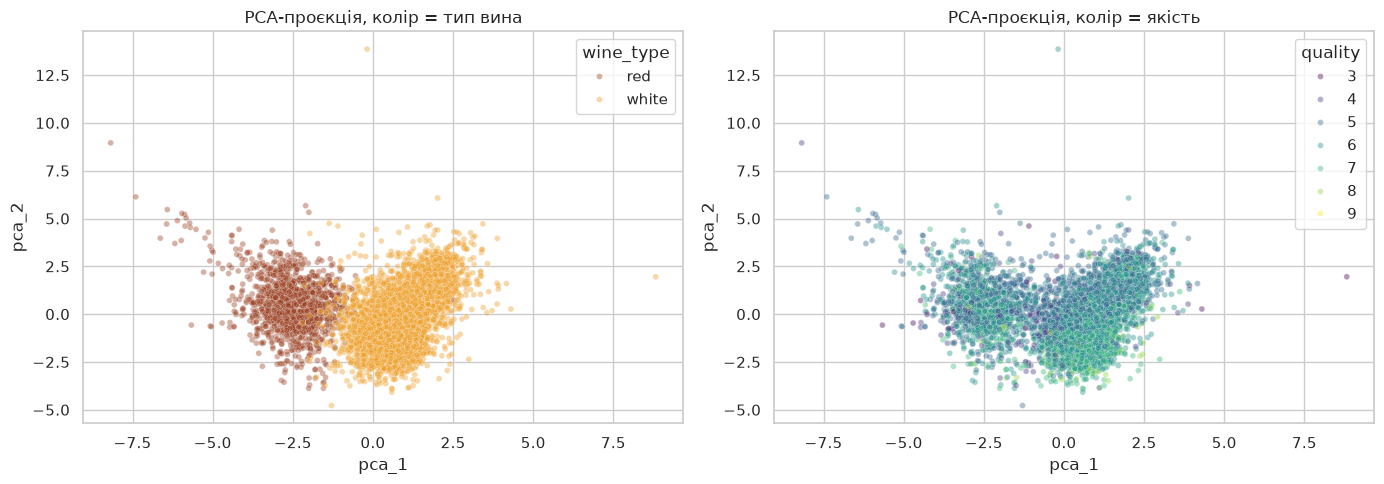

In [37]:
# Дивимось на ті самі дані у 2D-проєкції PCA, розфарбовані спочатку за типом вина...
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='wine_type', alpha=0.4, s=18,
                 palette={'red': '#993C1D', 'white': '#EF9F27'}, ax=axes[0])
axes[0].set_title('PCA-проєкція, колір = тип вина')

# ...а потім за оцінкою якості, щоб побачити, чи утворює якість власну структуру.
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='quality', alpha=0.4, s=18,
                 palette='viridis', ax=axes[1])
axes[1].set_title('PCA-проєкція, колір = якість')

plt.tight_layout()
plt.show()
# На лівому графіку типи вина зазвичай розділяються majestically чітко --
# підтверджує висновок з кластеризації. На правому оцінки якості
# розподілені більш "розмито" -- немає різкої межі, лише поступовий градієнт,
# що узгоджується зі скромним R² з розділу 4: якість не визначається
# хімією однозначно.

## Висновки

**Заповни цей розділ власними спостереженнями після запуску всіх клітинок.** Орієнтири та вже готові кількісні результати з коду вище:

- **Регресія (розділ 4):** лінійна модель дала R² ≈ 0.3 -- фізико-хімічні виміри пояснюють лише частину оцінки якості. Як ти думаєш, чому решту "не видно" в цих ознаках? (Підказка: смак дегустатора суб'єктивний і залежить не лише від хімії.)
- **Класифікація (розділ 5):** яка модель показала найвищу accuracy в підсумковій таблиці розділу 5.8? Чи узгоджується це з тим, що ти бачив на матриці плутанини?
- **Кластеризація (розділ 6.2-6.3):** наскільки чисто K-means і EM розділили вина на червоне/біле БЕЗ підказки? Що це говорить про те, наскільки різна хімія двох типів вина?
- **PCA (розділ 6.4):** скільки відсотків варіації пояснюють перші дві компоненти разом? Чи видно на PCA-графіку чіткіший поділ за типом вина, чи за якістю?
- **Загальний висновок:** які фізико-хімічні ознаки (дивись кореляційну матрицю розділу 3.4 та коефіцієнти регресії розділу 4.1) найсильніше пов'язані з високою оцінкою якості?
